In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, roc_auc_score

df = pd.read_csv('data/diabetes.csv')

# Replace 0 values with NaN for relevant columns
cols_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zeros] = df[cols_with_zeros].replace(0, np.nan)
df.fillna(df.median(), inplace=True)

# 1. Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows in the dataset: {duplicate_count}")

# Remove duplicates if any
df = df.drop_duplicates()

# 2. Outlier Detection using IQR method
def remove_outliers_iqr(df, columns):
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
    return df

# Applying outlier removal on relevant columns
df = remove_outliers_iqr(df, ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age'])

# 3. Feature Scaling (Standardization)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df.drop(['Outcome'], axis=1))
print("Feature scaling applied using StandardScaler.")



Duplicate rows in the dataset: 0
Feature scaling applied using StandardScaler.


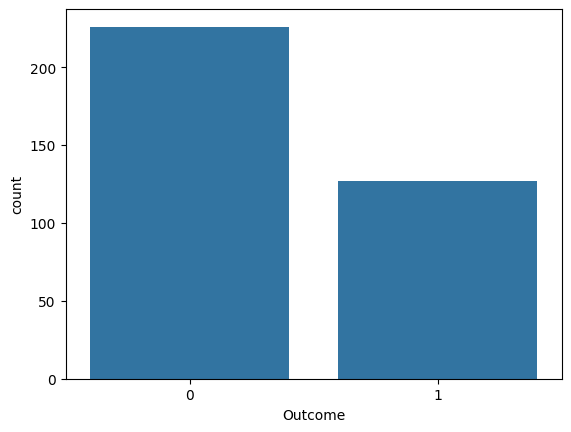

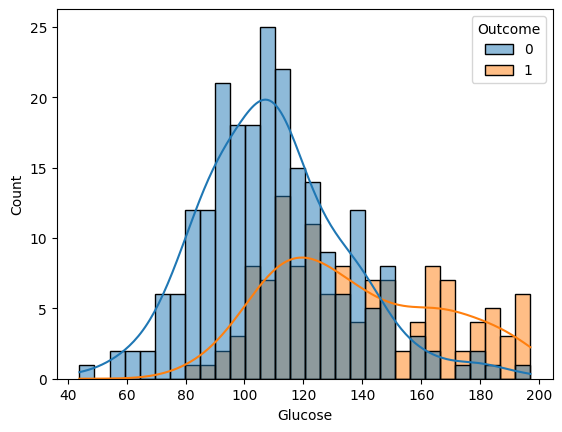

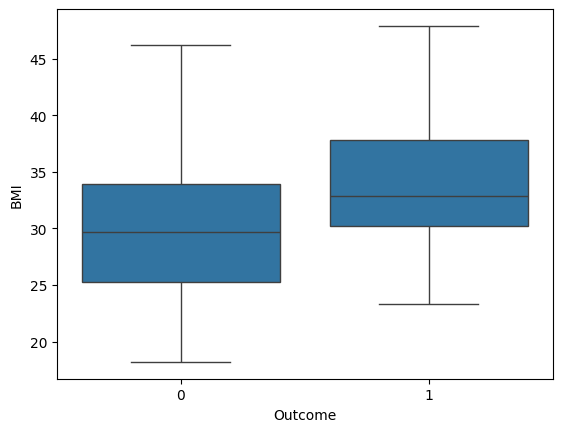

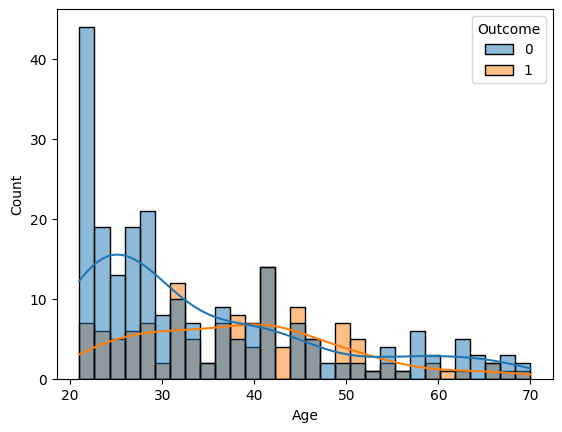

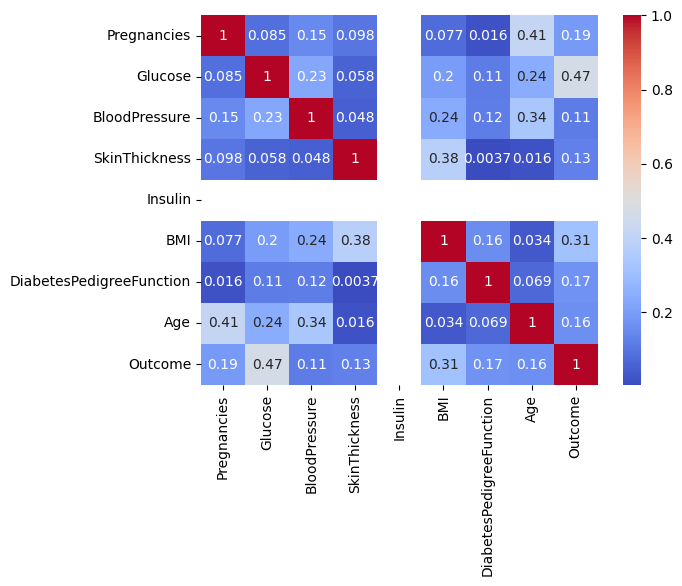

In [3]:
# EDA
sns.countplot(x='Outcome', data=df)
plt.show()

sns.histplot(data=df, x='Glucose', hue='Outcome', kde=True, bins=30)
plt.show()

sns.boxplot(x='Outcome', y='BMI', data=df)
plt.show()

sns.histplot(data=df, x='Age', hue='Outcome', kde=True, bins=30)
plt.show()

sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

In [4]:
# Plotly Dashboards
fig = px.pie(df, names='Outcome', title='Diabetes Distribution')
fig.show()

fig = px.histogram(df, x="Glucose", color="Outcome", nbins=30, barmode='overlay')
fig.show()

# Age Groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[20, 30, 40, 50, 60, 80], labels=['20–30', '31–40', '41–50', '51–60', '60+'])
fig = px.histogram(df, x='AgeGroup', color='Outcome', barmode='group')
fig.show()

fig = px.scatter(df, x="BMI", y="Glucose", color="Outcome")
fig.show()

Logistic Regression Accuracy: 0.704225352112676
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        45
           1       0.61      0.54      0.57        26

    accuracy                           0.70        71
   macro avg       0.68      0.67      0.67        71
weighted avg       0.70      0.70      0.70        71



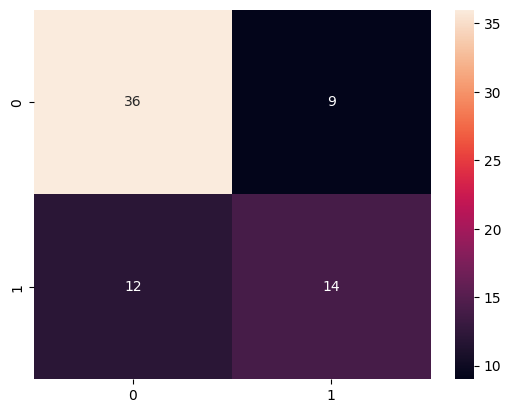

Decision Tree Accuracy: 0.647887323943662
              precision    recall  f1-score   support

           0       0.73      0.71      0.72        45
           1       0.52      0.54      0.53        26

    accuracy                           0.65        71
   macro avg       0.62      0.62      0.62        71
weighted avg       0.65      0.65      0.65        71



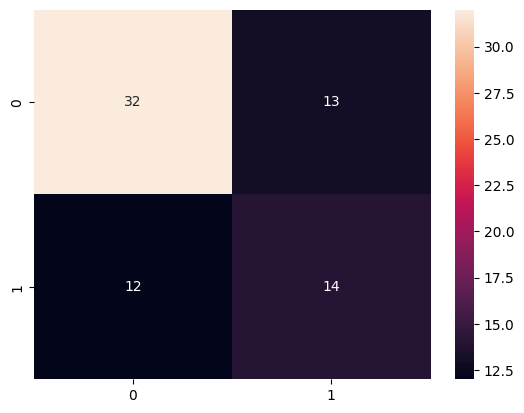

Random Forest Accuracy: 0.6901408450704225


In [5]:
# Model Building
X = df.drop(['Outcome', 'AgeGroup'], axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d')
plt.show()

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
sns.heatmap(confusion_matrix(y_test, y_pred_dt), annot=True, fmt='d')
plt.show()

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

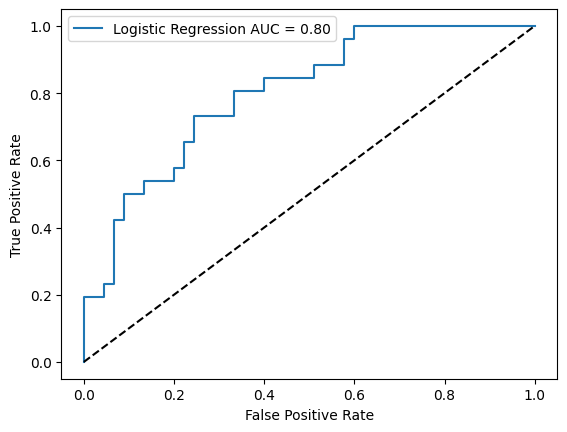

In [6]:
# ROC Curve
y_prob = logreg.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Logistic Regression AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

KNN Classifier Accuracy: 0.7323943661971831
              precision    recall  f1-score   support

           0       0.80      0.78      0.79        45
           1       0.63      0.65      0.64        26

    accuracy                           0.73        71
   macro avg       0.71      0.72      0.71        71
weighted avg       0.73      0.73      0.73        71



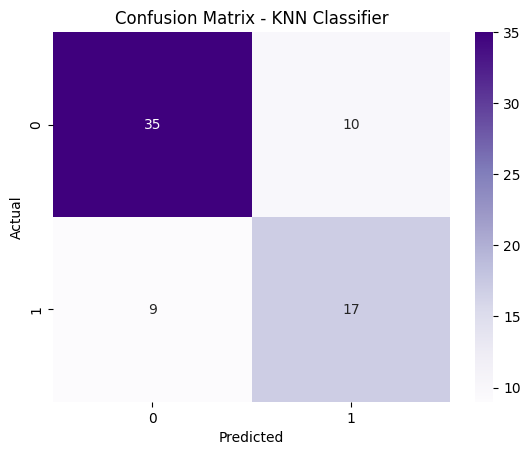

In [7]:

from sklearn.neighbors import KNeighborsClassifier

# KNN Model Building
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print("KNN Classifier Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))
sns.heatmap(confusion_matrix(y_test, y_pred_knn), annot=True, fmt='d', cmap='Purples')
plt.title("Confusion Matrix - KNN Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()